# Urbanisation

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pycountry

from conflict_monitoring_ntl.viz import (
    plot_world_coverage,
    plot_radiance_boxenplots,
    plot_lighted_proportion_comparison_by_urbanisation,
    plot_lighted_country_comparison_by_urbanisation,
    plot_regression_radiance_by_country,
)
from conflict_monitoring_ntl.config import SMOD_CLASS_ORDER, SMOD_CODE_MAPPING, PALETTE

In [2]:
CONTINENTS = [
    "Africa",
    "Asia",
    "Europe",
    "North America",
    "South America",
    "Oceania"
]

## Coverage

In [3]:
dfs = []

for continent in CONTINENTS:
    df = pd.read_parquet(
        "results/urbanization",
        filters=[("continent", "==",  continent)],
    )
    df = df[(~df.smod_code.isin([-200, 10])) & (df.black_marble_radiance_monthly >= 0)]
    high = df.black_marble_radiance_monthly.quantile(0.999)
    df = df[df.black_marble_radiance_monthly < high]
    df["bm_binary"] = df.black_marble_radiance_monthly > 1
    df["smod_class"] = df["smod_code"].map(SMOD_CODE_MAPPING)
    df["smod_class"] = pd.Categorical(
        df["smod_class"],
        categories=SMOD_CLASS_ORDER,
        ordered=True
    )

    df["country_name"] = df["country_code"].apply(
        lambda x: pycountry.countries.get(alpha_3=x).name
        if pycountry.countries.get(alpha_3=x)
        else "Invalid Code"
    )

    dfs.append(df)

df = pd.concat(dfs)
df.continent = df.continent.cat.remove_unused_categories()

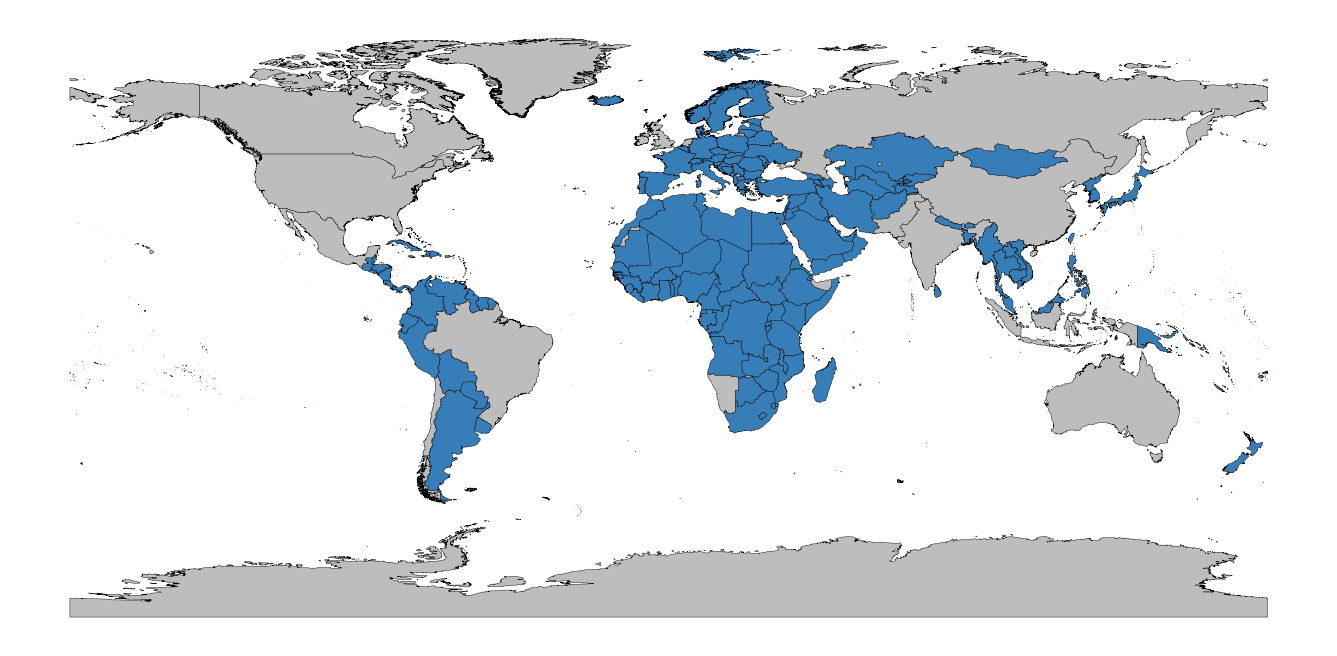

In [4]:
plot_world_coverage(
    country_names=df.country_name.unique().tolist(),
    country_codes=df.country_code.unique().tolist(),
)

## Radiance by Urbanisation Level

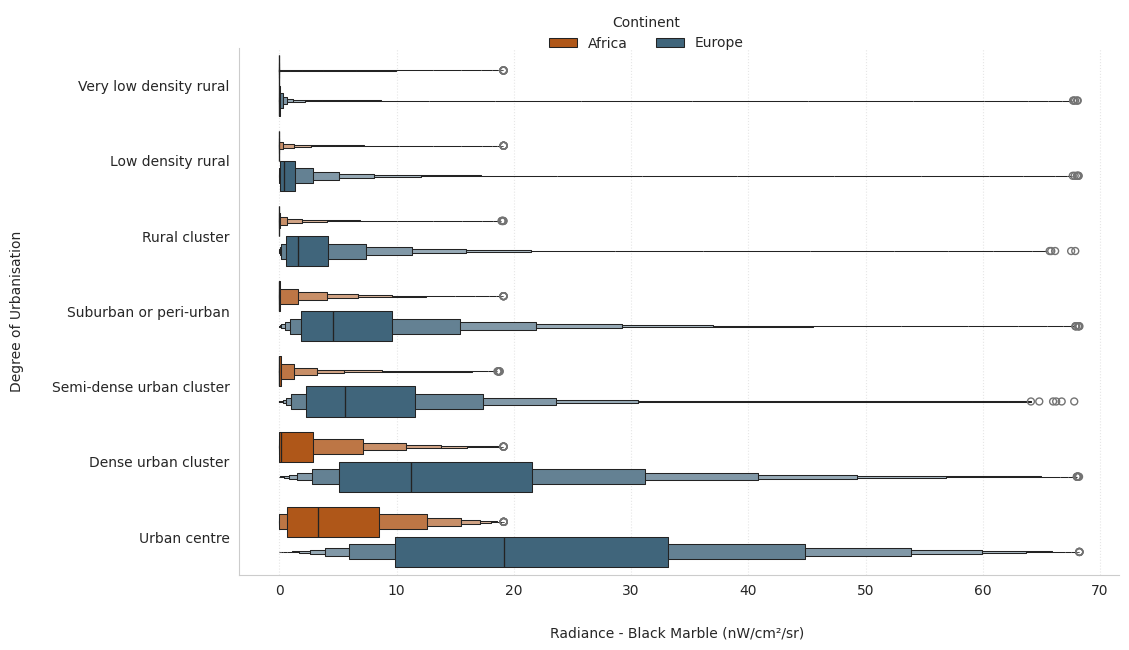

In [5]:
df_comparison = df[df.continent.isin(["Europe", "Africa"])].copy()
df_comparison["continent"] = df_comparison["continent"].cat.remove_unused_categories()

plot_radiance_boxenplots(df_comparison)

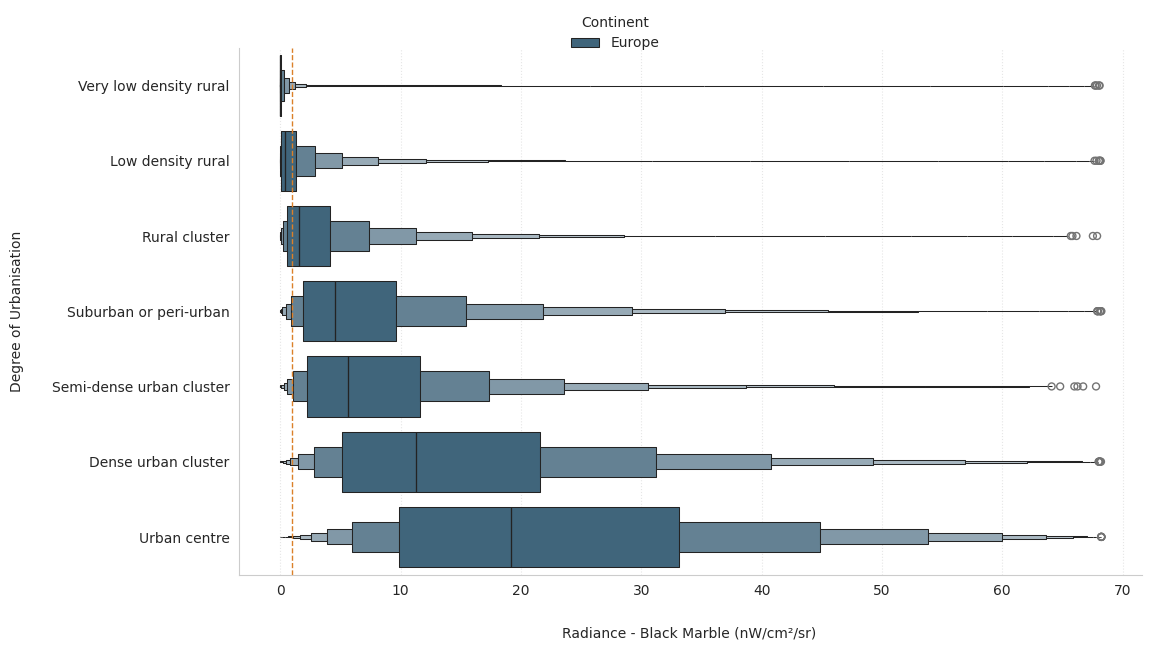

In [6]:
df_europe = df[df.continent.isin(["Europe"])].copy()
df_europe.continent = df_europe.continent.cat.remove_unused_categories()

plot_radiance_boxenplots(df_europe, vertical_line=1)

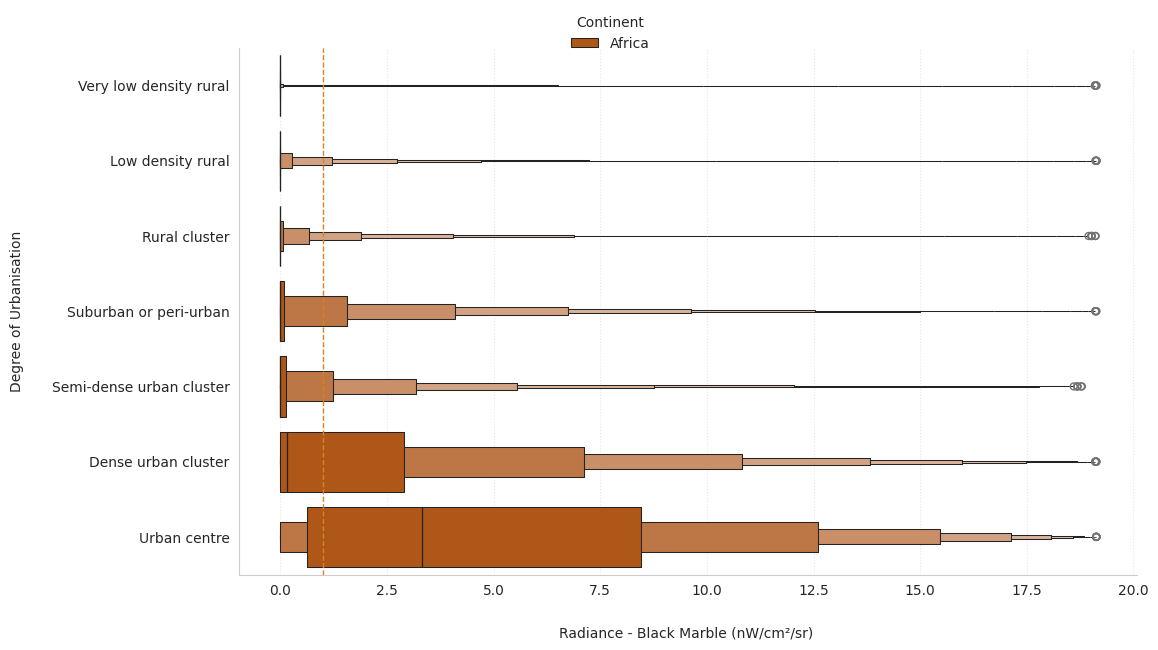

In [7]:
df_africa = df[df.continent.isin(["Africa"])].copy()
df_africa.continent = df_africa.continent.cat.remove_unused_categories()

plot_radiance_boxenplots(df_africa, vertical_line=1)

## Lighted Pixels

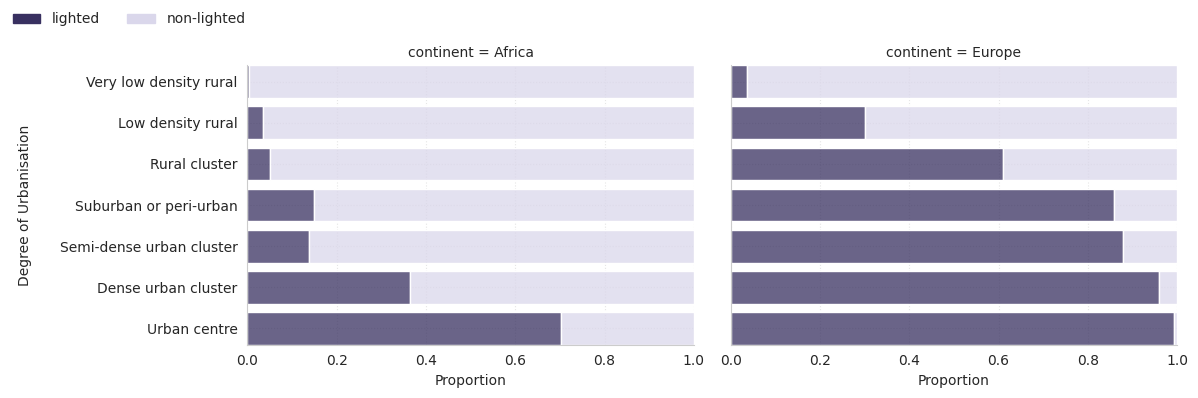

In [8]:
plot_lighted_proportion_comparison_by_urbanisation(df_comparison)

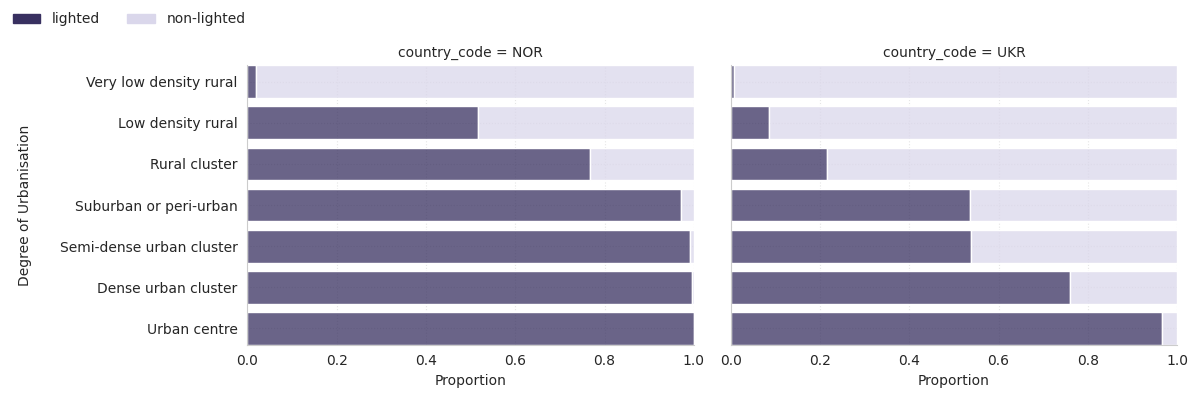

In [9]:
df_country = df[df.country_code.isin(["UKR", "NOR"])].copy()
df_country.country_code = df_country.country_code.cat.remove_unused_categories()
plot_lighted_proportion_comparison_by_urbanisation(df_country, col="country_code")

## Distribution of SMOD Classes

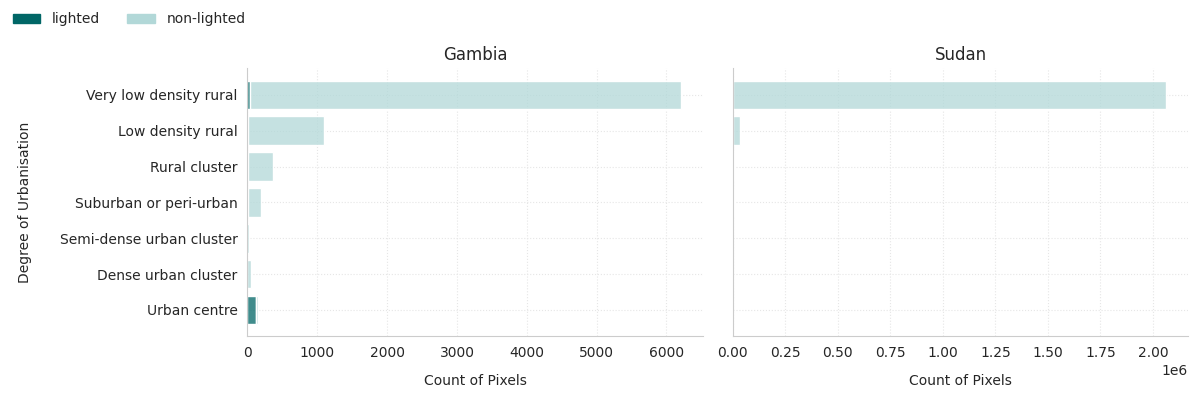

In [10]:
df_country = df[df.country_code.isin(["GMB", "SDN"])].copy()
df_country.country_code = df_country.country_code.cat.remove_unused_categories()
plot_lighted_country_comparison_by_urbanisation(df_country)

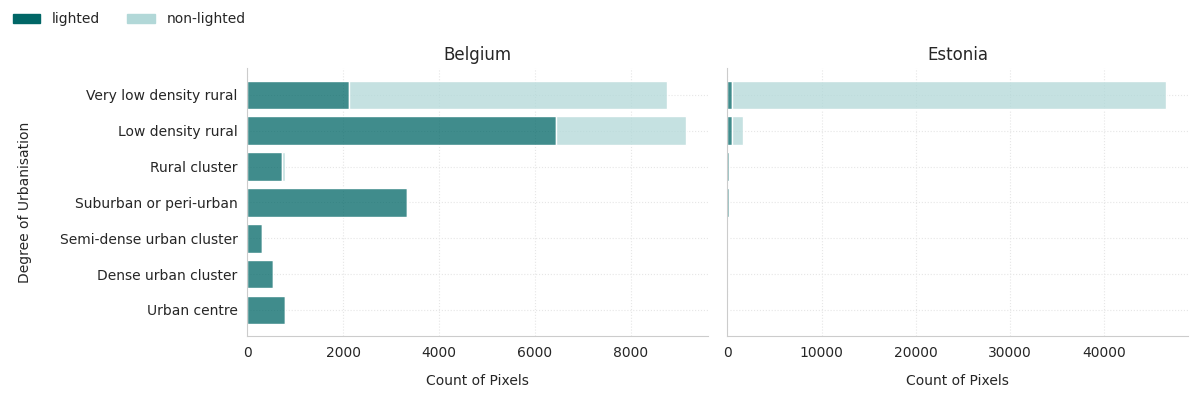

In [11]:
df_country = df[df.country_code.isin(["BEL", "EST"])].copy()
df_country.country_code = df_country.country_code.cat.remove_unused_categories()
plot_lighted_country_comparison_by_urbanisation(df_country)

In [12]:
cols_in_focus = ["continent", "country_code", "smod_class", "black_marble_radiance_monthly"]
df_radiance_grouped = df[cols_in_focus].groupby(
    by=["continent", "country_code", "smod_class"], observed=False
).mean().reset_index().dropna(subset="black_marble_radiance_monthly")

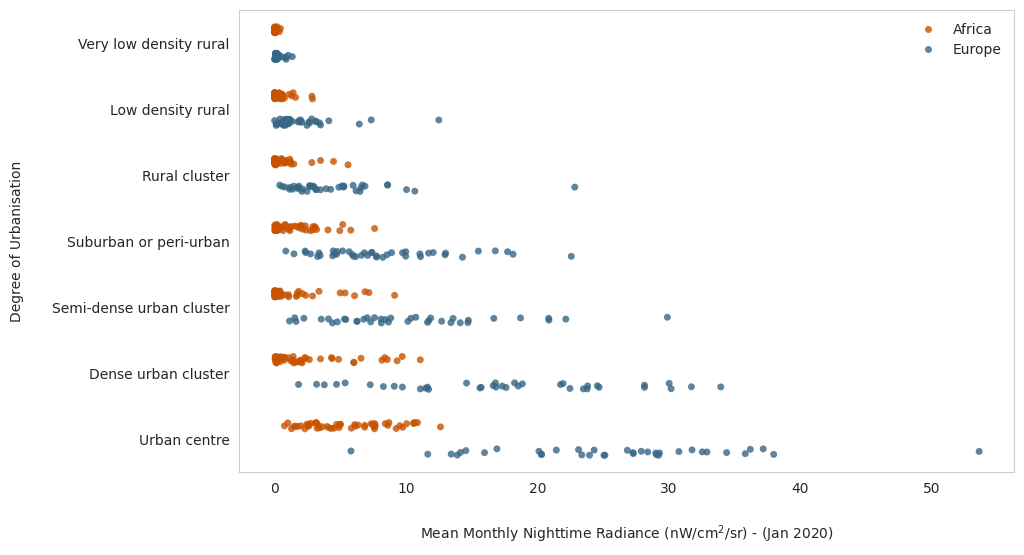

In [13]:
df_radiance_grouped = df_radiance_grouped[
    df_radiance_grouped.continent.isin(["Europe", "Africa"])
]
df_radiance_grouped["continent"] = df_radiance_grouped[
    "continent"
].cat.remove_unused_categories()

plt.figure(figsize=(10, 6))

with sns.axes_style("whitegrid", {"grid.color": "1.0"}):
    ax = sns.stripplot(
        data=df_radiance_grouped,
        x="black_marble_radiance_monthly",
        y="smod_class",
        hue="continent",
        dodge=True,
        alpha=0.8,
        palette=("#c85200", "#366785"),
    )

    ax.set_ylabel("Degree of Urbanisation", labelpad=20)
    ax.set_xlabel("Mean Monthly Nighttime Radiance (nW/cm$^2$/sr) - (Jan 2020)", labelpad=20)

    legend = plt.gca().get_legend()
    if legend:
        legend.set_frame_on(False)
        legend.set_title('')

## Relationship between HDI and Radiance by SMOD

In [14]:
df_radiance_europe = df_radiance_grouped[df_radiance_grouped.continent == "Europe"]
df_hdi = pd.read_csv("data/human_development_index.csv")[["iso3", "hdi_2020"]]

df_radiance_europe = pd.merge(
    left=df_radiance_europe, left_on="country_code", right=df_hdi, right_on="iso3"
)

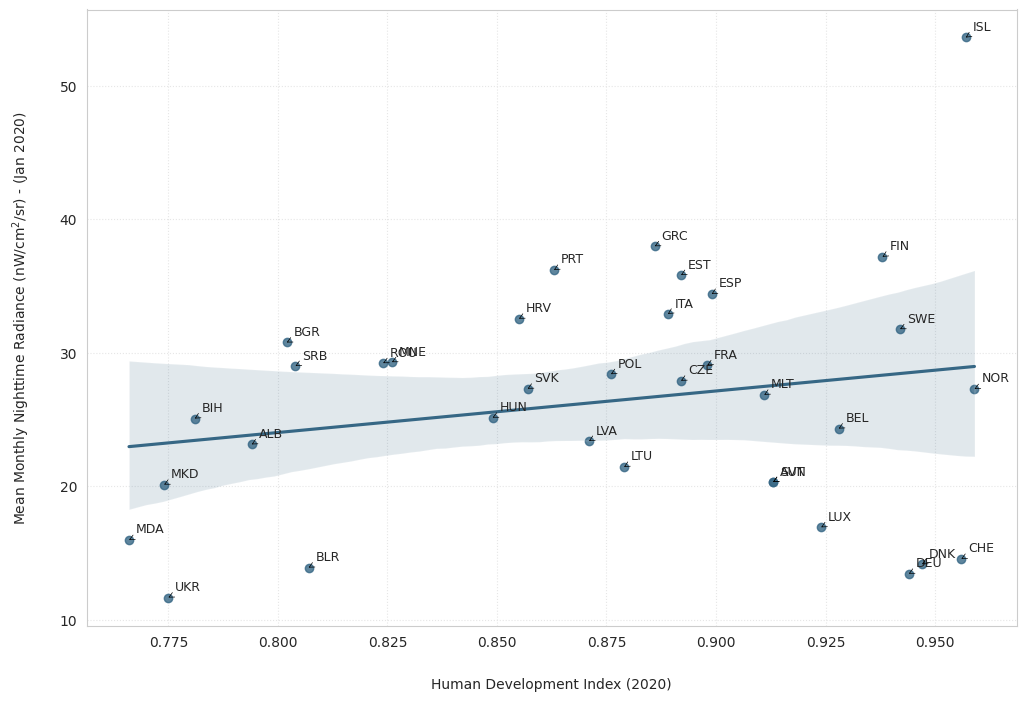

In [15]:
df_rad_urban_europe = df_radiance_europe[
    df_radiance_europe.smod_class == "Urban centre"
]

plot_regression_radiance_by_country(df_rad_urban_europe, color=PALETTE["Europe"])

<Figure size 1200x800 with 0 Axes>

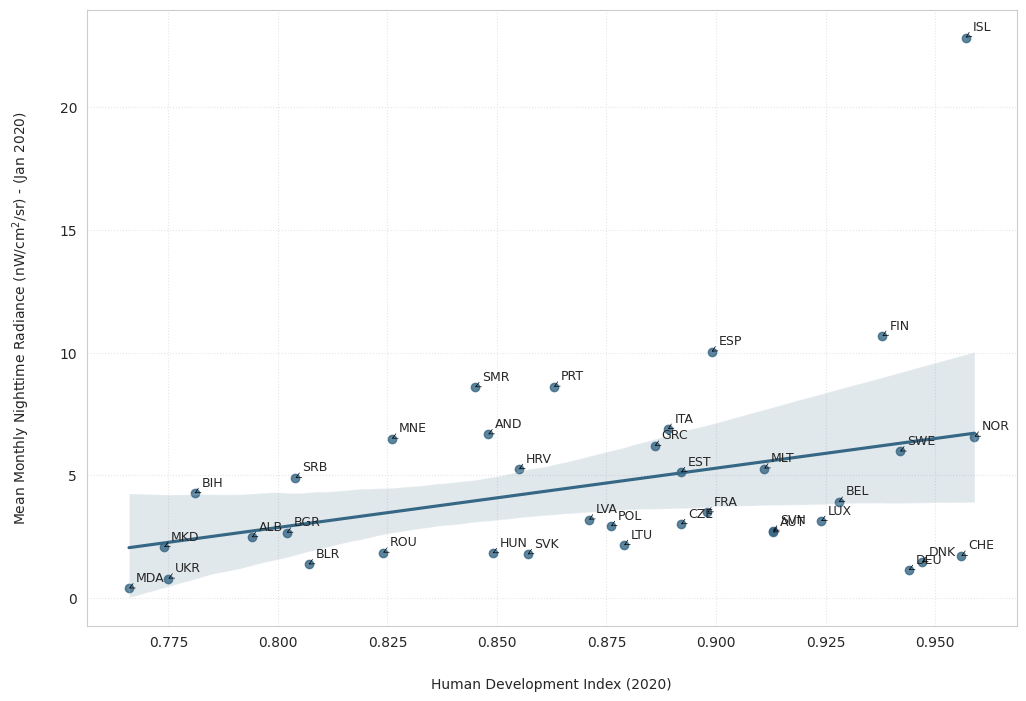

In [ ]:
df_rad_rural_europe = df_radiance_europe[
    df_radiance_europe.smod_class == "Rural cluster"
]

plot_regression_radiance_by_country(df_rad_rural_europe, color=PALETTE["Europe"])

In [17]:
df_radiance_africa = df_radiance_grouped[df_radiance_grouped.continent == "Africa"]
df_hdi = pd.read_csv("data/human_development_index.csv")[["iso3", "hdi_2020"]]

df_radiance_africa = pd.merge(
    left=df_radiance_africa, left_on="country_code", right=df_hdi, right_on="iso3"
)

<Figure size 1200x800 with 0 Axes>

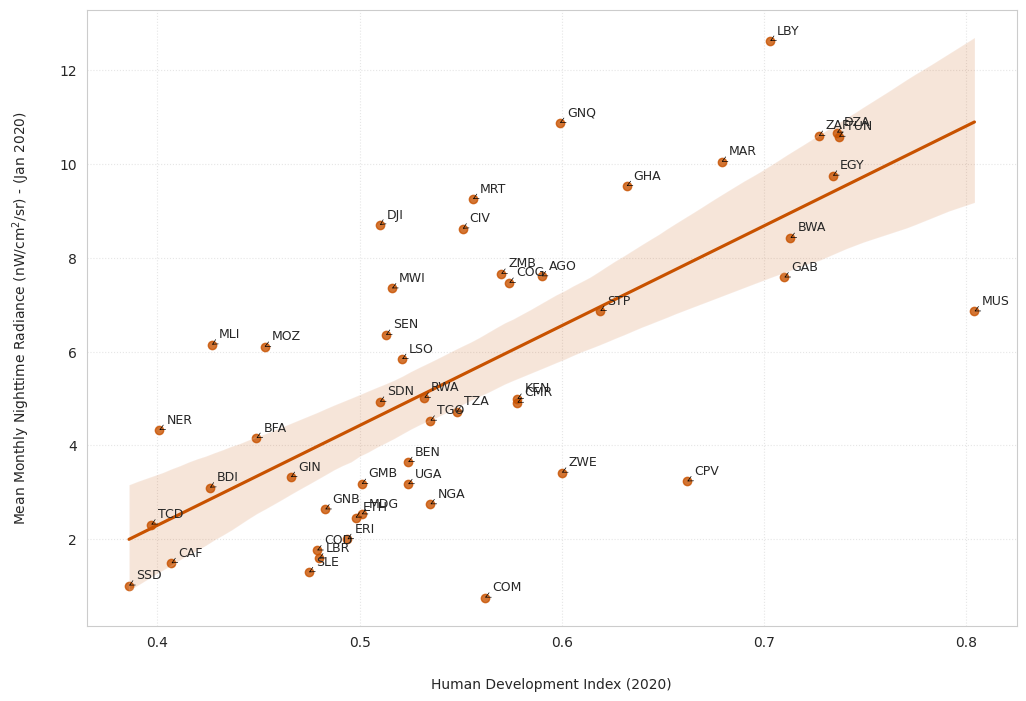

In [ ]:
df_rad_urban_africa = df_radiance_africa[
    df_radiance_africa.smod_class == "Urban centre"
]

plot_regression_radiance_by_country(df_rad_urban_africa, color=PALETTE["Africa"])

<Figure size 1200x800 with 0 Axes>

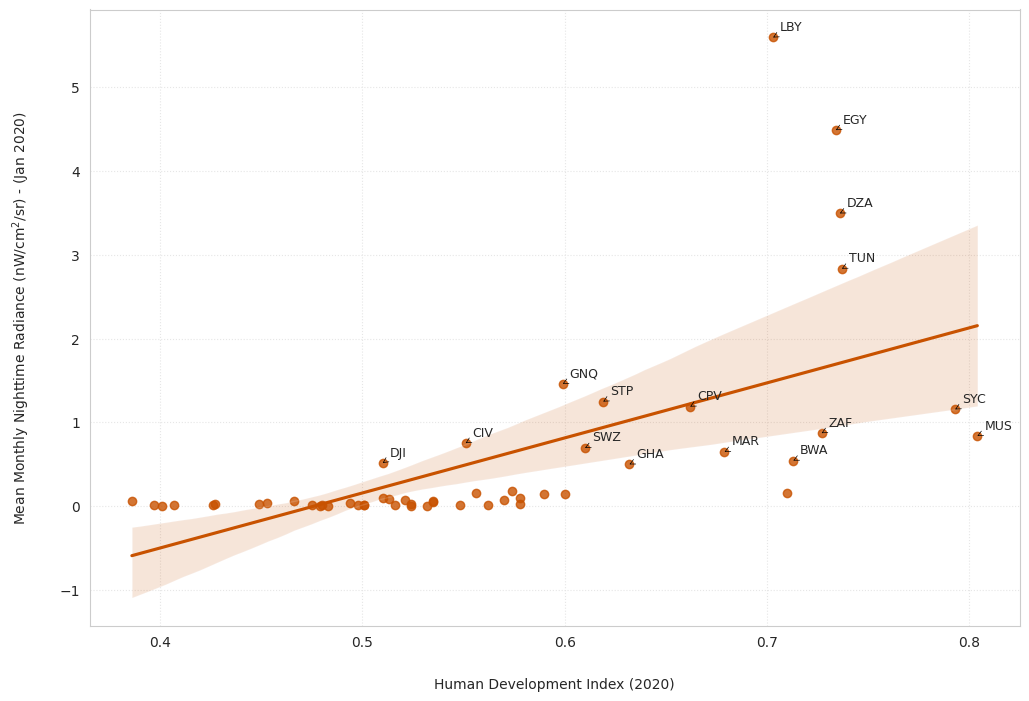

In [ ]:
df_rad_rural_africa = df_radiance_africa[
    df_radiance_africa.smod_class == "Rural cluster"
]

plot_regression_radiance_by_country(df_rad_rural_africa, color=PALETTE["Africa"])